In [1]:
!pip -q install -U datasets albumentations faster-coco-eval torchmetrics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.7/604.7 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.4 MB/s eta 0:00:00


## Set up and configuration

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    FasterRCNN_ResNet50_FPN_Weights
)

from torchvision.models.detection.faster_rcnn import (
    FastRCNNPredictor
)

TRAIN_SAMPLE_LIMIT = 3000
TEST_SAMPLE_LIMIT = 750

IMAGE_SIZE = 128

BATCH_SIZE = 4
EPOCHS = 5

NUM_CLASSES = 11

LR = 0.002
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

THRESHOLD = 0.8

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


## Loading SVHN Dataset

In [3]:
train_hf = load_dataset(
    "ufldl-stanford/svhn",
    name="full_numbers",
    split=f"train[:{TRAIN_SAMPLE_LIMIT}]"
)

test_hf = load_dataset(
    "ufldl-stanford/svhn",
    name="full_numbers",
    split=f"test[:{TEST_SAMPLE_LIMIT}]"
)

print("Train:", len(train_hf))
print("Test:", len(test_hf))

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

full_numbers/train-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B /  390MB            

full_numbers/train-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

full_numbers/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  272MB            

full_numbers/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

full_numbers/extra-00003-of-00004.parque(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/33402 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/13068 [00:00<?, ? examples/s]

Generating extra split:   0%|          | 0/202353 [00:00<?, ? examples/s]

Train: 3000
Test: 750


## Dataset and Preprocessing

In [4]:
class SVHNDataset(Dataset):

    def __init__(
        self,
        dataset,
        transform=None
    ):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        item = self.dataset[idx]

        image = np.array(
            item["image"].convert("RGB")
        )

        h, w = image.shape[:2]

        boxes = []
        labels = []

        for bbox, label in zip(
            item["digits"]["bbox"],
            item["digits"]["label"]
        ):

            x, y, bw, bh = map(
                float,
                bbox
            )

            x1 = max(
                0,
                min(x, w)
            )

            y1 = max(
                0,
                min(y, h)
            )

            x2 = max(
                0,
                min(x + bw, w)
            )

            y2 = max(
                0,
                min(y + bh, h)
            )

            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([
                x1,
                y1,
                x2,
                y2
            ])

            label = int(label)

            labels.append(
                1 if label == 10
                else label + 1
            )

        if self.transform:

            transformed = self.transform(
                image=image,
                bboxes=boxes,
                labels=labels
            )

            image = transformed["image"]
            boxes = transformed["bboxes"]
            labels = transformed["labels"]

        if not torch.is_tensor(image):

            image = torch.tensor(
                image.transpose(2, 0, 1),
                dtype=torch.float32
            ) / 255.0

        else:

            image = image.float()

            if image.max() > 1:
                image = image / 255.0

        boxes = torch.tensor(
            boxes,
            dtype=torch.float32
        ).reshape(-1, 4)

        labels = torch.tensor(
            labels,
            dtype=torch.int64
        )

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor(idx)
        }

        return image, target

In [5]:
base_transform = A.Compose(
    [

        A.LongestMaxSize(
            max_size=IMAGE_SIZE
        ),

        A.PadIfNeeded(
            min_height=IMAGE_SIZE,
            min_width=IMAGE_SIZE,
            border_mode=0,
            fill=0
        ),

        ToTensorV2()

    ],

    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["labels"],
        min_visibility=0.1
    )
)

##Data Loaders

In [6]:
train_dataset = SVHNDataset(
    train_hf,
    base_transform
)

test_dataset = SVHNDataset(
    test_hf,
    base_transform
)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fn
)

print("Datasets and loaders ready.")

Datasets and loaders ready.


## Sample Visualization

In [7]:
image, target = train_dataset[0]

print("Image:", image.shape)
print("Boxes:", target["boxes"].shape)
print("Labels:", target["labels"])

Image: torch.Size([3, 128, 128])
Boxes: torch.Size([2, 4])
Labels: tensor([5, 7])


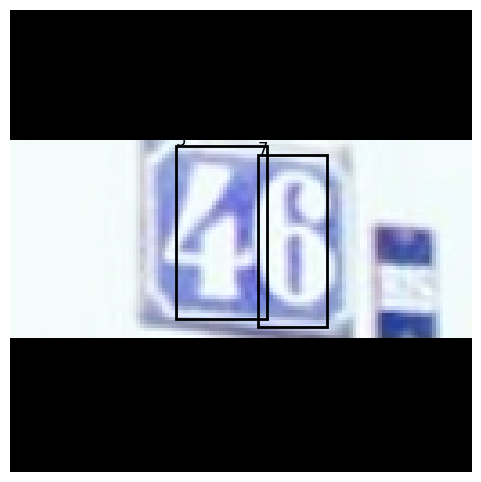

In [8]:
image, target = train_dataset[0]

image_np = image.permute(
    1, 2, 0
).numpy()

plt.figure(figsize=(6, 6))

plt.imshow(image_np)

for box, label in zip(
    target["boxes"],
    target["labels"]
):

    x1, y1, x2, y2 = box.numpy()

    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )
    )

    plt.text(
        x1,
        y1,
        str(label.item()),
        fontsize=12
    )

plt.axis("off")
plt.show()

## Faster R-CNN Model creation

In [9]:
def create_model():

    model = fasterrcnn_resnet50_fpn(
        weights=
        FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    )

    in_features = (
        model
        .roi_heads
        .box_predictor
        .cls_score
        .in_features
    )

    model.roi_heads.box_predictor = (
        FastRCNNPredictor(
            in_features,
            NUM_CLASSES
        )
    )

    model.to(DEVICE)

    return model

## Model Training

In [10]:
def train_model(model,loader):

    losses = []

    for epoch in range(EPOCHS):

        model.train()

        total_loss = 0

        for images, targets in loader:

            images = [
                x.to(DEVICE)
                for x in images
            ]

            targets = [
                {
                    k: v.to(DEVICE)
                    for k, v in t.items()
                }

                for t in targets
            ]

            optimizer.zero_grad(
                set_to_none=True
            )

            loss_dict = model(
                images,
                targets
            )

            loss = sum(
                loss_dict.values()
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = (
            total_loss /
            len(loader)
        )

        losses.append(avg_loss)

        print(
            f"Epoch {epoch + 1}/{EPOCHS} "
            f"- Loss: {avg_loss:.4f}"
        )

    return losses

In [12]:
print("BASELINE - SGD")

model = create_model()

optimizer = torch.optim.SGD(
    [
        p for p in model.parameters()
        if p.requires_grad
    ],
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

# Start timer
if torch.cuda.is_available():
    torch.cuda.synchronize()

start_time = time.time()

baseline_losses = train_model(
    model,
    train_loader
)

# Stop timer
if torch.cuda.is_available():
    torch.cuda.synchronize()

end_time = time.time()

training_time_seconds = (
    end_time - start_time
)

training_time_minutes = (
    training_time_seconds / 60
)

print(
    f"\nTraining time: "
    f"{training_time_seconds:.2f} seconds"
)

print(
    f"Training time: "
    f"{training_time_minutes:.2f} minutes"
)

# Save model
torch.save(
    model.state_dict(),
    "/content/baseline_sgd.pth"
)

print(
    "Saved: /content/baseline_sgd.pth"
)

BASELINE - SGD
Epoch 1/5 - Loss: 0.4309
Epoch 2/5 - Loss: 0.3041
Epoch 3/5 - Loss: 0.2693
Epoch 4/5 - Loss: 0.2464
Epoch 5/5 - Loss: 0.2294

Training time: 3340.71 seconds
Training time: 55.68 minutes
Saved: /content/baseline_sgd.pth


## Training Loss

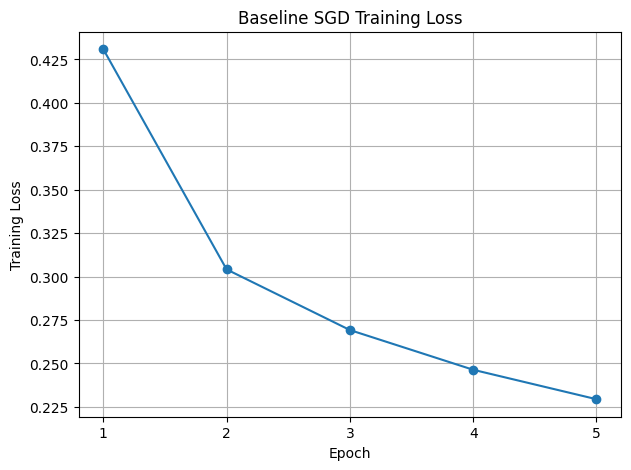

In [13]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, EPOCHS + 1),
    baseline_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Baseline SGD Training Loss")

plt.xticks(
    range(1, EPOCHS + 1)
)

plt.grid(True)

plt.show()

## Model Evaluation

In [14]:
from torchmetrics.detection.mean_ap import (
    MeanAveragePrecision
)

def evaluate(model):

    model.eval()

    map_metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
        iou_thresholds=[
            0.50,
            0.55,
            0.60,
            0.65,
            0.70,
            0.75,
            0.80,
            0.85,
            0.90,
            0.95
        ]
    )

    with torch.inference_mode():

        for images, targets in test_loader:

            images = [
                x.to(DEVICE)
                for x in images
            ]

            outputs = model(images)

            batch_preds = []
            batch_targets = []

            for output, target in zip(
                outputs,
                targets
            ):

                batch_preds.append({
                    "boxes":
                        output["boxes"].cpu(),

                    "scores":
                        output["scores"].cpu(),

                    "labels":
                        output["labels"].cpu()
                })

                batch_targets.append({
                    "boxes":
                        target["boxes"].cpu(),

                    "labels":
                        target["labels"].cpu()
                })

            map_metric.update(
                batch_preds,
                batch_targets
            )

    results = map_metric.compute()

    return {
        "mAP":
            results["map"].item(),

        "mAP50":
            results["map_50"].item(),

        "mAP75":
            results["map_75"].item()
    }

In [15]:
print("Evaluating Baseline - SGD")

metrics = evaluate(model)

print(metrics)

Evaluating Baseline - SGD
{'mAP': 0.31530874967575073, 'mAP50': 0.7408936619758606, 'mAP75': 0.19431903958320618}


## Table Result

In [16]:
results = pd.DataFrame([

    {
        "Experiment": "Baseline - SGD",

        "mAP":
            metrics["mAP"],

        "mAP50":
            metrics["mAP50"],

        "mAP75":
            metrics["mAP75"]

    }

])

display(results)

,Experiment,mAP,mAP50,mAP75
0,Baseline - SGD,0.315309,0.740894,0.194319
